In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Téléchargement du dataset Adult Income...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

colonnes = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
            "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
            "hours-per-week", "native-country", "income"]

df = pd.read_csv(url, names=colonnes, na_values="?", skipinitialspace=True)


df = df.dropna()
print(f"Taille du dataset après nettoyage : {df.shape[0]} lignes.")


X = df.drop("income", axis=1)
y = df["income"]

encoder_y = LabelEncoder()
y = encoder_y.fit_transform(y)

X = pd.get_dummies(X, drop_first=True)


X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Apprentissage : {X_train.shape[0]} exemples")
print(f"Validation : {X_val.shape[0]} exemples")
print(f"Test : {X_test.shape[0]} exemples")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("\nPréparation terminée avec succès. Les données sont prêtes pour PyTorch.")

Téléchargement du dataset Adult Income...
Taille du dataset après nettoyage : 30162 lignes.
Apprentissage : 21124 exemples
Validation : 4513 exemples
Test : 4525 exemples

Préparation terminée avec succès. Les données sont prêtes pour PyTorch.


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).view(-1, 1)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


input_dim = X_train.shape[1]
print(f"Dimension d'entrée du modèle : {input_dim} neurones")

mlp_sequential = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)


class CustomMLP(nn.Module):
    def __init__(self, input_dim):
        super(CustomMLP, self).__init__()
        self.couche1 = nn.Linear(input_dim, 64)
        self.activation1 = nn.ReLU()
        self.couche2 = nn.Linear(64, 32)
        self.activation2 = nn.ReLU()
        self.sortie = nn.Linear(32, 1)
        self.activation_sortie = nn.Sigmoid()

    def forward(self, x):
        x = self.couche1(x)
        x = self.activation1(x)
        x = self.couche2(x)
        x = self.activation2(x)
        x = self.sortie(x)
        x = self.activation_sortie(x)
        return x

mlp_custom = CustomMLP(input_dim)

print("Les deux modèles ont été créés avec succès.")

Dimension d'entrée du modèle : 96 neurones
Les deux modèles ont été créés avec succès.


In [3]:

print("--- Inspection via state_dict() ---")
for nom_parametre, tenseur in mlp_custom.state_dict().items():
    print(f"{nom_parametre} : dimension {tenseur.size()}")

print("\n--- Inspection via named_parameters() ---")
for nom, parametre in mlp_custom.named_parameters():
    if parametre.requires_grad:
        print(f"Le paramètre '{nom}' va être mis à jour par rétropropagation.")



def init_constante(module):
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 0.5)
        nn.init.constant_(module.bias, 0.0)

def init_gaussienne(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.01)
        nn.init.constant_(module.bias, 0.0)

def init_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.constant_(module.bias, 0.0)

mlp_constant = CustomMLP(input_dim)
mlp_constant.apply(init_constante)

mlp_gaussien = CustomMLP(input_dim)
mlp_gaussien.apply(init_gaussienne)

mlp_xavier = CustomMLP(input_dim)
mlp_xavier.apply(init_xavier)

print("\nLes trois modèles ont été initialisés avec succès.")

--- Inspection via state_dict() ---
couche1.weight : dimension torch.Size([64, 96])
couche1.bias : dimension torch.Size([64])
couche2.weight : dimension torch.Size([32, 64])
couche2.bias : dimension torch.Size([32])
sortie.weight : dimension torch.Size([1, 32])
sortie.bias : dimension torch.Size([1])

--- Inspection via named_parameters() ---
Le paramètre 'couche1.weight' va être mis à jour par rétropropagation.
Le paramètre 'couche1.bias' va être mis à jour par rétropropagation.
Le paramètre 'couche2.weight' va être mis à jour par rétropropagation.
Le paramètre 'couche2.bias' va être mis à jour par rétropropagation.
Le paramètre 'sortie.weight' va être mis à jour par rétropropagation.
Le paramètre 'sortie.bias' va être mis à jour par rétropropagation.

Les trois modèles ont été initialisés avec succès.


In [4]:
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"L'entraînement s'effectuera sur : {device}")

modele = mlp_xavier.to(device)


criterion = nn.BCELoss()

optimizer = torch.optim.Adam(modele.parameters(), lr=0.001)


epochs = 20
meilleure_loss_val = float('inf')
meilleurs_poids = None

print("\nDébut de l'entraînement...")

for epoch in range(epochs):
    modele.train()
    loss_train_totale = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        predictions = modele(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_train_totale += loss.item()

    loss_train_moyenne = loss_train_totale / len(train_loader)

    modele.eval()
    loss_val_totale = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = modele(X_batch)
            loss = criterion(predictions, y_batch)
            loss_val_totale += loss.item()

    loss_val_moyenne = loss_val_totale / len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Loss Train: {loss_train_moyenne:.4f} | Loss Val: {loss_val_moyenne:.4f}")

    if loss_val_moyenne < meilleure_loss_val:
        meilleure_loss_val = loss_val_moyenne
        meilleurs_poids = copy.deepcopy(modele.state_dict())


chemin_sauvegarde = "meilleur_mlp_adult_income.pth"
torch.save(meilleurs_poids, chemin_sauvegarde)
print(f"\nMeilleur modèle sauvegardé sous '{chemin_sauvegarde}'")

modele_recharge = CustomMLP(input_dim).to(device)
modele_recharge.load_state_dict(torch.load(chemin_sauvegarde))
print("Le modèle a été rechargé avec succès depuis le disque.")

L'entraînement s'effectuera sur : cpu

Début de l'entraînement...
Epoch 1/20 | Loss Train: 0.3769 | Loss Val: 0.3301
Epoch 2/20 | Loss Train: 0.3297 | Loss Val: 0.3267
Epoch 3/20 | Loss Train: 0.3186 | Loss Val: 0.3236
Epoch 4/20 | Loss Train: 0.3109 | Loss Val: 0.3238
Epoch 5/20 | Loss Train: 0.3074 | Loss Val: 0.3242
Epoch 6/20 | Loss Train: 0.3049 | Loss Val: 0.3242
Epoch 7/20 | Loss Train: 0.2984 | Loss Val: 0.3249
Epoch 8/20 | Loss Train: 0.2948 | Loss Val: 0.3288
Epoch 9/20 | Loss Train: 0.2921 | Loss Val: 0.3261
Epoch 10/20 | Loss Train: 0.2888 | Loss Val: 0.3334
Epoch 11/20 | Loss Train: 0.2872 | Loss Val: 0.3297
Epoch 12/20 | Loss Train: 0.2848 | Loss Val: 0.3304
Epoch 13/20 | Loss Train: 0.2841 | Loss Val: 0.3328
Epoch 14/20 | Loss Train: 0.2826 | Loss Val: 0.3391
Epoch 15/20 | Loss Train: 0.2793 | Loss Val: 0.3389
Epoch 16/20 | Loss Train: 0.2761 | Loss Val: 0.3410
Epoch 17/20 | Loss Train: 0.2753 | Loss Val: 0.3383
Epoch 18/20 | Loss Train: 0.2715 | Loss Val: 0.3438
Epoch 1

--- RÉSULTATS DE L'ÉVALUATION ---
Accuracy (Précision globale) : 0.8482
Precision (Justesse)         : 0.7115
Recall (Sensibilité)         : 0.6539
F1-Score                     : 0.6815


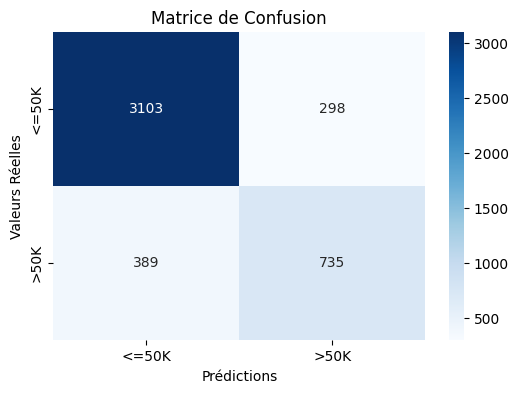

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


modele_recharge.eval()

predictions_test = []
cibles_test = []

with torch.no_grad():
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        probabilites = modele_recharge(X_batch)

        classes_predites = (probabilites >= 0.5).float().cpu().numpy()

        predictions_test.extend(classes_predites)
        cibles_test.extend(y_batch.numpy())

acc = accuracy_score(cibles_test, predictions_test)
prec = precision_score(cibles_test, predictions_test)
rec = recall_score(cibles_test, predictions_test)
f1 = f1_score(cibles_test, predictions_test)

print("--- RÉSULTATS DE L'ÉVALUATION ---")
print(f"Accuracy (Précision globale) : {acc:.4f}")
print(f"Precision (Justesse)         : {prec:.4f}")
print(f"Recall (Sensibilité)         : {rec:.4f}")
print(f"F1-Score                     : {f1:.4f}")

cm = confusion_matrix(cibles_test, predictions_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Matrice de Confusion')
plt.ylabel('Valeurs Réelles')
plt.xlabel('Prédictions')
plt.show()

In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

print(f"Images d'apprentissage : {len(trainset)}")
print(f"Images de test : {len(testset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 342kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.34MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.6MB/s]

Images d'apprentissage : 60000
Images de test : 10000


In [7]:
def correlation_croisee_2d(X, K):
    """
    Calcule la corrélation croisée 2D basique entre une image (X) et un filtre (K).
    Sans padding, avec un stride de 1.
    """
    h_X, w_X = X.shape
    h_K, w_K = K.shape

    h_Y = h_X - h_K + 1
    w_Y = w_X - w_K + 1

    Y = torch.zeros((h_Y, w_Y))

    for i in range(h_Y):
        for j in range(w_Y):
            Y[i, j] = (X[i:i+h_K, j:j+w_K] * K).sum()
    return Y

def max_pooling_2d(X, pool_size):
    """
    Implémentation manuelle du Max-Pooling.
    La taille du pas (stride) est égale à la taille du filtre de pooling.
    """
    p_h, p_w = pool_size
    h_X, w_X = X.shape

    h_Y = h_X // p_h
    w_Y = w_X // p_w

    Y = torch.zeros((h_Y, w_Y))

    for i in range(h_Y):
        for j in range(w_Y):
            Y[i, j] = X[i*p_h : (i+1)*p_h, j*p_w : (j+1)*p_w].max()
    return Y

def avg_pooling_2d(X, pool_size):
    """
    Implémentation manuelle de l'Average-Pooling.
    """
    p_h, p_w = pool_size
    h_X, w_X = X.shape

    h_Y = h_X // p_h
    w_Y = w_X // p_w

    Y = torch.zeros((h_Y, w_Y))

    for i in range(h_Y):
        for j in range(w_Y):
            Y[i, j] = X[i*p_h : (i+1)*p_h, j*p_w : (j+1)*p_w].mean()
    return Y

print("\n--- Test des implémentations manuelles ---")
image_test = torch.tensor([[0.0, 1.0, 2.0],
                           [3.0, 4.0, 5.0],
                           [6.0, 7.0, 8.0]])
filtre_test = torch.tensor([[0.0, 1.0],
                            [2.0, 3.0]])

sortie_manuelle_conv = correlation_croisee_2d(image_test, filtre_test)
print("Sortie de notre Corrélation Croisée 2D :\n", sortie_manuelle_conv)

image_pool = torch.tensor([[0., 1., 2., 3.], [4., 5., 6., 7.], [8., 9., 10., 11.], [12., 13., 14., 15.]])
sortie_manuelle_pool = max_pooling_2d(image_pool, (2, 2))
print("\nSortie de notre Max-Pooling 2x2 :\n", sortie_manuelle_pool)


--- Test des implémentations manuelles ---
Sortie de notre Corrélation Croisée 2D :
 tensor([[19., 25.],
        [37., 43.]])

Sortie de notre Max-Pooling 2x2 :
 tensor([[ 5.,  7.],
        [13., 15.]])


In [8]:
import torch.nn.functional as F

print("--- Comparaison avec PyTorch ---")

image_pt = image_test.view(1, 1, 3, 3)
filtre_pt = filtre_test.view(1, 1, 2, 2)

sortie_pt_conv = F.conv2d(image_pt, filtre_pt)
print("PyTorch Conv2D :\n", sortie_pt_conv.squeeze())
print("Correspondance exacte ?", torch.allclose(sortie_manuelle_conv, sortie_pt_conv.squeeze()))

image_pool_pt = image_pool.view(1, 1, 4, 4)
sortie_pt_pool = F.max_pool2d(image_pool_pt, kernel_size=2, stride=2)
print("\nPyTorch MaxPool2D :\n", sortie_pt_pool.squeeze())
print("Correspondance exacte ?", torch.allclose(sortie_manuelle_pool, sortie_pt_pool.squeeze()))

--- Comparaison avec PyTorch ---
PyTorch Conv2D :
 tensor([[19., 25.],
        [37., 43.]])
Correspondance exacte ? True

PyTorch MaxPool2D :
 tensor([[ 5.,  7.],
        [13., 15.]])
Correspondance exacte ? True


In [9]:
import torch.nn as nn

class LeNetCustom(nn.Module):
    def __init__(self, utiliser_max_pool=True, utiliser_conv_1x1=False, filtres_c1=6, filtres_c2=16):
        super(LeNetCustom, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=filtres_c1, kernel_size=5, padding=2, stride=1)
        self.relu1 = nn.ReLU()

        if utiliser_max_pool:
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=filtres_c1, out_channels=filtres_c2, kernel_size=5)
        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) if utiliser_max_pool else nn.AvgPool2d(kernel_size=2, stride=2)

        self.utiliser_conv_1x1 = utiliser_conv_1x1
        if self.utiliser_conv_1x1:
            self.conv1x1 = nn.Conv2d(in_channels=filtres_c2, out_channels=filtres_c2, kernel_size=1)
            self.relu_1x1 = nn.ReLU()

        self.fc1 = nn.Linear(filtres_c2 * 5 * 5, 120)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(120, 84)
        self.relu4 = nn.ReLU()
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        if self.utiliser_conv_1x1:
            x = self.relu_1x1(self.conv1x1(x))

        x = x.view(-1, x.size(1) * x.size(2) * x.size(3))

        x = self.relu3(self.fc1(x))
        x = self.relu4(self.fc2(x))
        x = self.fc3(x)
        return x

cnn_model = LeNetCustom(utiliser_max_pool=True, utiliser_conv_1x1=False).to(device)
print(cnn_model)

LeNetCustom(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (relu4): ReLU()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [10]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

epochs_cnn = 5

print("--- Début de l'entraînement du CNN ---")
for epoch in range(epochs_cnn):
    cnn_model.train()
    loss_totale = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        sorties = cnn_model(images)
        loss = criterion_cnn(sorties, labels)
        loss.backward()
        optimizer_cnn.step()

        loss_totale += loss.item()

    print(f"Époque {epoch+1}/{epochs_cnn} - Loss moyenne : {loss_totale/len(trainloader):.4f}")

cnn_model.eval()
predictions_cnn = []
cibles_cnn = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        sorties = cnn_model(images)
        _, classes_predites = torch.max(sorties.data, 1)

        predictions_cnn.extend(classes_predites.cpu().numpy())
        cibles_cnn.extend(labels.numpy())

accuracy_cnn = accuracy_score(cibles_cnn, predictions_cnn)
print(f"\nPrécision (Accuracy) du CNN sur les données de test : {accuracy_cnn * 100:.2f}%")

--- Début de l'entraînement du CNN ---
Époque 1/5 - Loss moyenne : 0.5779
Époque 2/5 - Loss moyenne : 0.3582
Époque 3/5 - Loss moyenne : 0.3095
Époque 4/5 - Loss moyenne : 0.2831
Époque 5/5 - Loss moyenne : 0.2634

Précision (Accuracy) du CNN sur les données de test : 88.91%


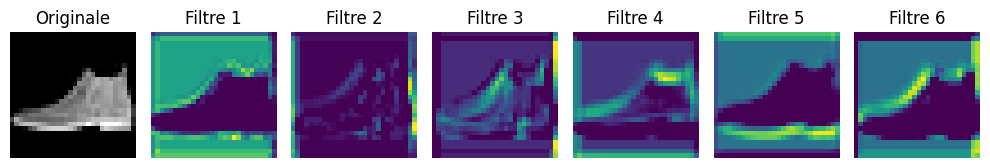

In [11]:
import matplotlib.pyplot as plt

images_test, labels_test = next(iter(testloader))
image_unique = images_test[0].unsqueeze(0).to(device)

cnn_model.eval()
with torch.no_grad():
    carte_activation = cnn_model.relu1(cnn_model.conv1(image_unique))

plt.figure(figsize=(10, 4))
plt.subplot(1, 7, 1)
plt.imshow(image_unique.cpu().squeeze(), cmap='gray')
plt.title("Originale")
plt.axis('off')

for i in range(6):
    plt.subplot(1, 7, i + 2)
    feature_map = carte_activation[0, i, :, :].cpu().numpy()
    plt.imshow(feature_map, cmap='viridis')
    plt.title(f"Filtre {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import re
from collections import Counter

corpus_anglais = [
    "hello", "how are you", "i am fine", "what is your name",
    "my name is ai", "good morning", "see you later", "i like deep learning"
]
corpus_francais = [
    "bonjour", "comment vas tu", "je vais bien", "quel est ton nom",
    "mon nom est ia", "bonjour", "a plus tard", "j aime le deep learning"
]

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
special_tokens = ['<pad>', '<unk>', '<sos>', '<eos>']

def construire_vocabulaire(corpus):
    mots = []
    for phrase in corpus:
        mots.extend(phrase.split())
    compteur = Counter(mots)
    vocab = special_tokens + list(compteur.keys())
    word2idx = {mot: idx for idx, mot in enumerate(vocab)}
    return word2idx, vocab

word2idx_eng, vocab_eng = construire_vocabulaire(corpus_anglais)
word2idx_fra, vocab_fra = construire_vocabulaire(corpus_francais)

print(f"Taille du vocabulaire Anglais : {len(vocab_eng)} mots")
print(f"Taille du vocabulaire Français : {len(vocab_fra)} mots")


def preparer_sequence(phrase, word2idx, max_len=6):
    mots = phrase.split()
    indices = [word2idx.get(m, UNK_IDX) for m in mots]

    indices = [SOS_IDX] + indices + [EOS_IDX]

    if len(indices) < max_len:
        indices += [PAD_IDX] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
        indices[-1] = EOS_IDX

    return torch.tensor(indices)

X_seq = torch.stack([preparer_sequence(p, word2idx_eng) for p in corpus_anglais])
Y_seq = torch.stack([preparer_sequence(p, word2idx_fra) for p in corpus_francais])

seq_dataset = torch.utils.data.TensorDataset(X_seq, Y_seq)
seq_loader = torch.utils.data.DataLoader(seq_dataset, batch_size=2, shuffle=True)

print("\nExemple d'une phrase encodée (Anglais) :", X_seq[1].tolist())

Taille du vocabulaire Anglais : 24 mots
Taille du vocabulaire Français : 25 mots

Exemple d'une phrase encodée (Anglais) : [2, 5, 6, 7, 3, 0]


In [13]:
import torch.nn as nn

class EncodeurTextuel(nn.Module):
    def __init__(self, taille_vocabulaire, dim_embedding, dim_cachee, type_modele='RNN'):
        super(EncodeurTextuel, self).__init__()
        self.type_modele = type_modele
        self.dim_cachee = dim_cachee

        self.embedding = nn.Embedding(taille_vocabulaire, dim_embedding)

        if type_modele == 'RNN':
            self.recurrent = nn.RNN(dim_embedding, dim_cachee, batch_first=True)
        elif type_modele == 'LSTM':
            self.recurrent = nn.LSTM(dim_embedding, dim_cachee, batch_first=True)
        elif type_modele == 'GRU':
            self.recurrent = nn.GRU(dim_embedding, dim_cachee, batch_first=True)

    def forward(self, x):
        x_embed = self.embedding(x)

        if self.type_modele == 'LSTM':
            sorties, (h_n, c_n) = self.recurrent(x_embed)
            return sorties, h_n, c_n
        else:
            sorties, h_n = self.recurrent(x_embed)
            return sorties, h_n

dim_embedding = 16
dim_cachee = 32

encodeur_rnn = EncodeurTextuel(len(vocab_eng), dim_embedding, dim_cachee, 'RNN')
encodeur_lstm = EncodeurTextuel(len(vocab_eng), dim_embedding, dim_cachee, 'LSTM')
encodeur_gru = EncodeurTextuel(len(vocab_eng), dim_embedding, dim_cachee, 'GRU')

print("Les trois architectures ont été générées avec succès.")

Les trois architectures ont été générées avec succès.


In [14]:
optimizer_rnn = torch.optim.Adam(encodeur_rnn.parameters(), lr=0.001)
criterion_seq = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

encodeur_rnn.train()

X_batch, Y_batch = next(iter(seq_loader))

sorties, h_n = encodeur_rnn(X_batch)

loss = sorties.sum()

optimizer_rnn.zero_grad()
loss.backward()

torch.nn.utils.clip_grad_norm_(encodeur_rnn.parameters(), max_norm=1.0)

optimizer_rnn.step()
print("Gradient calculé, plafonné (clippé) et poids mis à jour en toute sécurité.")

Gradient calculé, plafonné (clippé) et poids mis à jour en toute sécurité.


In [15]:
import random

class DecodeurTextuel(nn.Module):
    def __init__(self, taille_vocabulaire, dim_embedding, dim_cachee, type_modele='GRU'):
        super(DecodeurTextuel, self).__init__()
        self.type_modele = type_modele

        self.embedding = nn.Embedding(taille_vocabulaire, dim_embedding)

        if type_modele == 'GRU':
            self.recurrent = nn.GRU(dim_embedding, dim_cachee, batch_first=True)

        self.fc_out = nn.Linear(dim_cachee, taille_vocabulaire)

    def forward(self, input_mot, cachee):
        input_mot = input_mot.unsqueeze(1)

        embed = self.embedding(input_mot)
        sortie, cachee = self.recurrent(embed, cachee)

        prediction = self.fc_out(sortie.squeeze(1))
        return prediction, cachee


class Seq2Seq(nn.Module):
    def __init__(self, encodeur, decodeur, device):
        super(Seq2Seq, self).__init__()
        self.encodeur = encodeur
        self.decodeur = decodeur
        self.device = device

    def forward(self, source, cible, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        longueur_cible = cible.shape[1]
        taille_vocab_cible = self.decodeur.fc_out.out_features

        sorties = torch.zeros(batch_size, longueur_cible, taille_vocab_cible).to(self.device)

        _, cachee = self.encodeur(source)

        input_mot = cible[:, 0]

        for t in range(1, longueur_cible):
            prediction, cachee = self.decodeur(input_mot, cachee)
            sorties[:, t] = prediction

            meilleur_mot = prediction.argmax(1)

            teacher_force = random.random() < teacher_forcing_ratio
            input_mot = cible[:, t] if teacher_force else meilleur_mot

        return sorties

decodeur = DecodeurTextuel(len(vocab_fra), dim_embedding=16, dim_cachee=32, type_modele='GRU')
modele_traduction = Seq2Seq(encodeur_gru, decodeur, device).to(device)

print("Architecture Seq2Seq prête pour l'entraînement.")

Architecture Seq2Seq prête pour l'entraînement.


In [16]:
def decodage_glouton(modele, phrase_source_tensor, max_len=10):
    modele.eval()
    with torch.no_grad():
        _, cachee = modele.encodeur(phrase_source_tensor)

        input_mot = torch.tensor([2]).to(device)
        mots_generes = []

        for _ in range(max_len):
            prediction, cachee = modele.decodeur(input_mot, cachee)
            meilleur_mot = prediction.argmax(1).item()

            if meilleur_mot == 3:
                break

            mots_generes.append(meilleur_mot)
            input_mot = torch.tensor([meilleur_mot]).to(device)

    return mots_generes

def beam_search(modele, phrase_source_tensor, largeur_faisceau=2, max_len=10):
    """
    Au lieu de garder 1 seul mot, on garde les 'k' meilleures séquences en cours de construction.
    """
    modele.eval()
    with torch.no_grad():
        _, cachee_initiale = modele.encodeur(phrase_source_tensor)

        faisceaux = [(0.0, [2], cachee_initiale)]

        for _ in range(max_len):
            nouveaux_faisceaux = []

            for score, sequence, cachee in faisceaux:
                dernier_mot = sequence[-1]

                if dernier_mot == 3:
                    nouveaux_faisceaux.append((score, sequence, cachee))
                    continue

                input_mot = torch.tensor([dernier_mot]).to(device)
                prediction, nouvelle_cachee = modele.decodeur(input_mot, cachee)

                probabilites = torch.log_softmax(prediction, dim=1).squeeze()

                top_scores, top_mots = probabilites.topk(largeur_faisceau)

                for i in range(largeur_faisceau):
                    nouveau_score = score + top_scores[i].item()
                    nouvelle_seq = sequence + [top_mots[i].item()]
                    nouveaux_faisceaux.append((nouveau_score, nouvelle_seq, nouvelle_cachee))

            nouveaux_faisceaux.sort(key=lambda x: x[0], reverse=True)
            faisceaux = nouveaux_faisceaux[:largeur_faisceau]

            if all(f[1][-1] == 3 for f in faisceaux):
                break

    meilleure_sequence = faisceaux[0][1][1:]
    if meilleure_sequence and meilleure_sequence[-1] == 3:
        meilleure_sequence = meilleure_sequence[:-1]

    return meilleure_sequence

print("Fonctions de génération Greedy et Beam Search opérationnelles.")

Fonctions de génération Greedy et Beam Search opérationnelles.


In [17]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

mlp_vision = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

optimizer_mlp_vis = optim.Adam(mlp_vision.parameters(), lr=0.001)
criterion_vis = nn.CrossEntropyLoss()

print("--- Entraînement du MLP sur Fashion-MNIST ---")
mlp_vision.train()
for epoch in range(5):
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer_mlp_vis.zero_grad()
        sorties = mlp_vision(images)
        loss = criterion_vis(sorties, labels)
        loss.backward()
        optimizer_mlp_vis.step()

mlp_vision.eval()
predictions_mlp_vis, cibles_mlp_vis = [], []
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        sorties = mlp_vision(images)
        _, classes_predites = torch.max(sorties, 1)
        predictions_mlp_vis.extend(classes_predites.cpu().numpy())
        cibles_mlp_vis.extend(labels.numpy())

acc_mlp_vis = accuracy_score(cibles_mlp_vis, predictions_mlp_vis)
print(f"Accuracy du CNN (précédent) : {accuracy_cnn * 100:.2f}%")
print(f"Accuracy du MLP (actuel)    : {acc_mlp_vis * 100:.2f}%")
print("-> Conclusion : Le CNN est nettement supérieur car il conserve la structure spatiale 2D de l'image.")

--- Entraînement du MLP sur Fashion-MNIST ---
Accuracy du CNN (précédent) : 88.91%
Accuracy du MLP (actuel)    : 86.59%
-> Conclusion : Le CNN est nettement supérieur car il conserve la structure spatiale 2D de l'image.


In [18]:
def evaluer_variante_cnn(modele_variante, nom_test):
    modele_variante = modele_variante.to(device)
    optimizer = optim.Adam(modele_variante.parameters(), lr=0.001)

    modele_variante.train()
    for _ in range(2):
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion_cnn(modele_variante(images), labels)
            loss.backward()
            optimizer.step()

    modele_variante.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            sorties = modele_variante(images)
            _, pred = torch.max(sorties, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    print(f"Variante '{nom_test}' : Accuracy = {100 * correct / total:.2f}%")

print("--- Lancement de l'étude architecturale CNN ---")
evaluer_variante_cnn(LeNetCustom(utiliser_max_pool=True, utiliser_conv_1x1=False), "Modèle de Base (Max Pool)")
evaluer_variante_cnn(LeNetCustom(utiliser_max_pool=False, utiliser_conv_1x1=False), "Average Pooling")
evaluer_variante_cnn(LeNetCustom(utiliser_max_pool=True, utiliser_conv_1x1=True), "Ajout Convolution 1x1")


--- Lancement de l'étude architecturale CNN ---
Variante 'Modèle de Base (Max Pool)' : Accuracy = 87.08%
Variante 'Average Pooling' : Accuracy = 83.87%
Variante 'Ajout Convolution 1x1' : Accuracy = 86.16%


In [19]:
import time
import math

def entrainer_et_evaluer_modele(type_modele):
    encodeur_test = EncodeurTextuel(len(vocab_eng), dim_embedding=16, dim_cachee=32, type_modele=type_modele).to(device)
    optimizer = torch.optim.Adam(encodeur_test.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    encodeur_test.train()
    debut_temps = time.time()

    for epoch in range(10):
        loss_totale = 0
        for X_batch, Y_batch in seq_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()

            if type_modele == 'LSTM':
                sorties, _, _ = encodeur_test(X_batch)
            else:
                sorties, _ = encodeur_test(X_batch)

            sorties = sorties.reshape(-1, sorties.shape[-1])
            Y_batch_flat = Y_batch.reshape(-1)

            loss = criterion(sorties, Y_batch_flat)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(encodeur_test.parameters(), max_norm=1.0)
            optimizer.step()
            loss_totale += loss.item()

    temps_ecoule = time.time() - debut_temps
    loss_moyenne = loss_totale / len(seq_loader)

    perplexite = math.exp(loss_moyenne)

    print(f"Modèle {type_modele} | Temps: {temps_ecoule:.2f}s | Loss: {loss_moyenne:.4f} | Perplexité: {perplexite:.2f}")

print("--- Comparaison Expérimentale des Séquences ---")
entrainer_et_evaluer_modele('RNN')
entrainer_et_evaluer_modele('LSTM')
entrainer_et_evaluer_modele('GRU')

--- Comparaison Expérimentale des Séquences ---
Modèle RNN | Temps: 0.16s | Loss: 2.1918 | Perplexité: 8.95
Modèle LSTM | Temps: 0.24s | Loss: 2.4802 | Perplexité: 11.94
Modèle GRU | Temps: 0.14s | Loss: 2.3444 | Perplexité: 10.43
